# Scenario discovery: PRIM and CART on the seven-factor set, at 2030 and 2050

CART first (an easy-to-read tree) then PRIM (a tuned box), run **twice** - once on the 2030 value of
each factor and once on the 2050 value - for the outcome

**`desired_success`** = net-zero CO2 by 2070 *and* below-threshold cumulative CCS reliance
(built in [01_build_dataset.ipynb](01_build_dataset.ipynb)).

Running the same workflow at both horizons shows whether the desired region is already legible in
near-term (2030) structure or only emerges in the 2050 energy/climate mix.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from ema_workbench.analysis import cart, prim

pd.set_option("display.max_columns", 60)

data = pd.read_csv("data_for_scenariodiscovery_full.csv")
data["desired_success"] = data["desired_success"].astype(bool)
print(data.shape)

(1599, 207)


## 1. Outcome and factors

Outcome: `desired_success`. The seven factors below are each evaluated at the snapshot year under
analysis (we run 2030 and 2050 separately).

**Caveat on circularity.** Two of these factors are climate/technology *outputs* tightly linked to
the outcome definition: median GSAT temperature is largely a function of cumulative CO2 (so close to
net-zero timing), and BECCS (`Carbon Capture|Geological Storage|Biomass`) is a component of the
cumulative-CCS total used to define `low_ccs_reliance`. Boxes that lean on those two should be read
as *descriptive* ("desired pathways also show low BECCS / low warming"), not as independent leading
indicators. The genuinely forward-looking signal is in the energy-mix and near-term-CO2 factors.

In [ ]:
OUTCOME = "desired_success"
SNAPSHOT_YEARS = [2040, 2050]

BASE_FACTORS = [
    # "Emissions|CO2",
    "Primary Energy|Fossil",
    "Primary Energy|Biomass",
    "Primary Energy",
    "Primary Energy|Non-Biomass Renewables",
    # "Carbon Capture|Geological Storage",
    "Final Energy|Electricity",
    # "Climate Assessment|Surface Temperature (GSAT)|Median [MAGICCv7.5.3]",
]

## 2. One reusable pass: CART then PRIM

`run_discovery(year)` builds the factor columns for that year, drops scenarios missing any factor,
fits a CART tree (saved as a figure), then runs PRIM, picks a point on the peeling trade-off (among
boxes with coverage >= 0.8, the densest), inspects it, and checks for a second box (equifinality).
Every figure is saved with a year suffix so the 2030 and 2050 outputs don't overwrite each other.

In [19]:
def run_discovery(year, coverage_floor=0.8):
    factors = [f"{v}|{year}" for v in BASE_FACTORS]
    sub = data[factors + [OUTCOME]].dropna()
    x = sub[factors]
    y = sub[OUTCOME].values
    print(f"===== {year} =====")
    print(f"{len(sub)}/{len(data)} scenarios complete on all {len(factors)} factors")
    print(f"{y.sum()} desired cases, baseline density = {y.mean():.1%}\n")

    # --- CART: a readable decision tree --------------------------------------
    cart_alg = cart.CART(x, y)
    cart_alg.build_tree()
    fig = cart_alg.show_tree()
    fig.set_size_inches((20, 13))
    fig.savefig(f"cart_tree_desired_success_{year}.png", dpi=150, bbox_inches="tight")
    plt.show()

    imp = pd.Series(cart_alg.clf.feature_importances_, index=factors).sort_values(ascending=False)
    print("CART feature importances (non-zero):")
    display(imp[imp > 0].to_frame("importance"))

    # --- PRIM: tuned box on the desired region -------------------------------
    prim_alg = prim.Prim(x, y, threshold=0.1)
    box1 = prim_alg.find_box()
    box1.show_tradeoff()
    plt.gcf().suptitle(f"PRIM peeling trade-off, box 1 ({year})")
    plt.savefig(f"prim_tradeoff_box1_{year}.png", dpi=150, bbox_inches="tight")
    plt.show()

    traj = box1.peeling_trajectory
    cand = traj[traj["coverage"] >= coverage_floor]
    selected = int(cand.loc[cand["density"].idxmax(), "id"])
    print(f"selected box {selected} (coverage >= {coverage_floor}, max density)")
    box1.select(selected)
    box1.inspect(selected)
    box1.inspect(selected, style="graph")
    plt.gcf().set_size_inches((10, 6))
    plt.gcf().suptitle(f"PRIM box 1 restricted dimensions ({year})")
    plt.savefig(f"prim_box1_graph_{year}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- equifinality: a second box on the residual --------------------------
    box2 = prim_alg.find_box()
    if box2 is None or len(box2.peeling_trajectory) <= 1:
        print("No meaningful second box - box 1 already covers the desired region.")
    else:
        box2.show_tradeoff()
        plt.gcf().suptitle(f"PRIM peeling trade-off, box 2 ({year})")
        plt.savefig(f"prim_tradeoff_box2_{year}.png", dpi=150, bbox_inches="tight")
        plt.show()

    print(f"\nPRIM box statistics ({year}):")
    display(prim_alg.stats_to_dataframe())
    return prim_alg

## 3. Run at 2030 (near-term structure)

===== 2040 =====
1370/1599 scenarios complete on all 6 factors
322 desired cases, baseline density = 23.5%



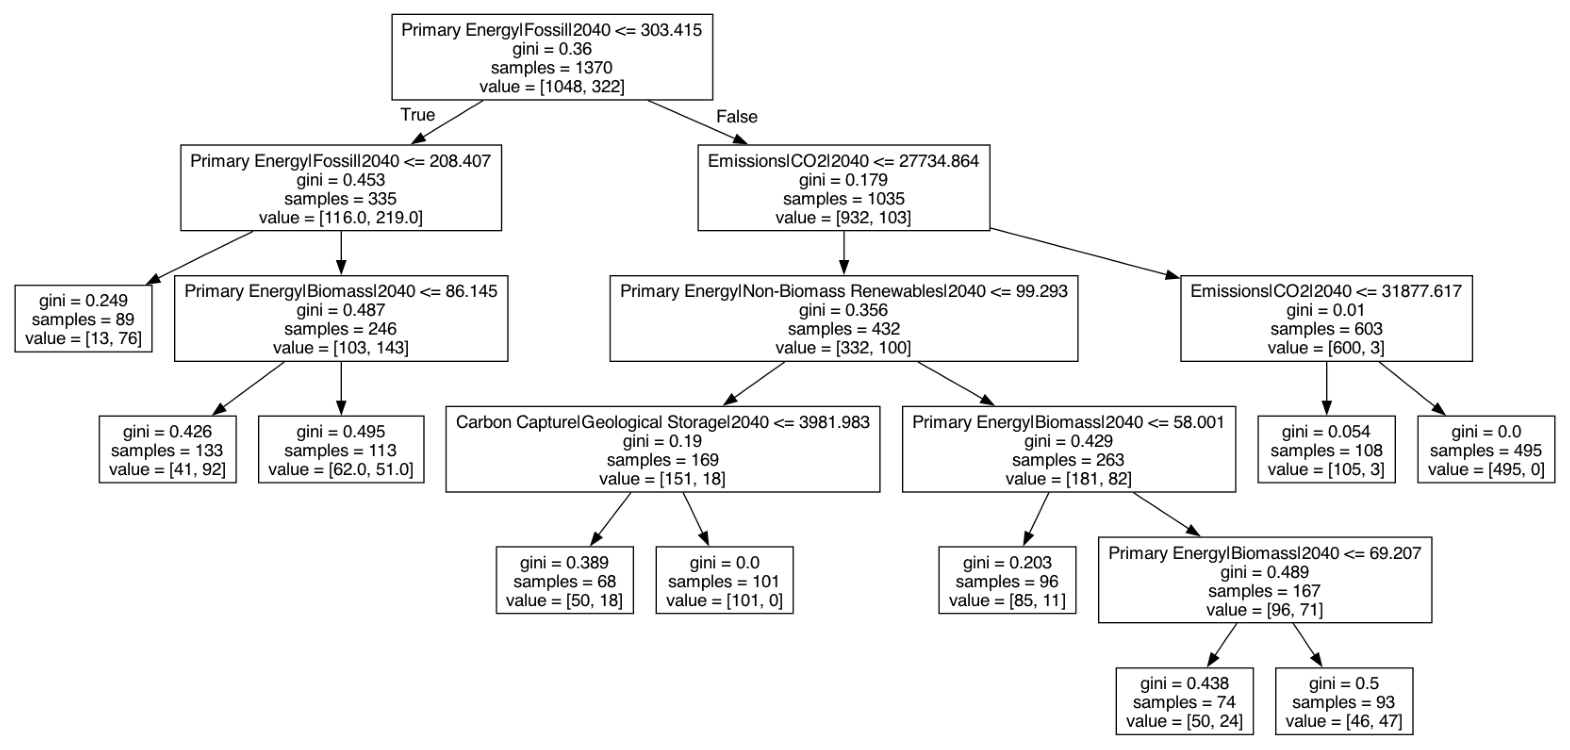

CART feature importances (non-zero):


,importance
Primary Energy|Fossil|2040,0.727574
Emissions|CO2|2040,0.114353
Primary Energy|Biomass|2040,0.094796
Primary Energy|Non-Biomass Renewables|2040,0.038192
Carbon Capture|Geological Storage|2040,0.025084


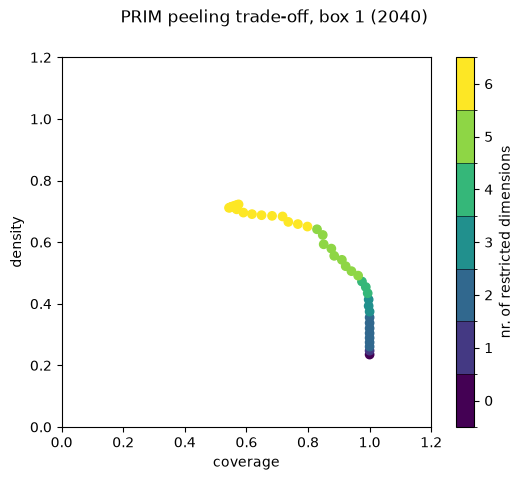

selected box 23 (coverage >= 0.8, max density)
coverage      0.829193
density       0.641827
id           23.000000
k           267.000000
mass          0.303650
mean          0.641827
n           416.000000
res_dim       5.000000
Name: 23, dtype: float64

                                                 box 23                \
                                                    min           max   
Emissions|CO2|2040                         -8000.004968  25001.923303   
Carbon Capture|Geological Storage|2040         0.000000  11313.036763   
Primary Energy|Fossil|2040                    90.634800    429.908984   
Primary Energy|Non-Biomass Renewables|2040   102.933709    299.656686   
Primary Energy|Biomass|2040                   54.162647    252.594724   

                                                                
                                            qp value  qp value  
Emissions|CO2|2040                               NaN  0.002762  
Carbon Capture|Geological Storage|20

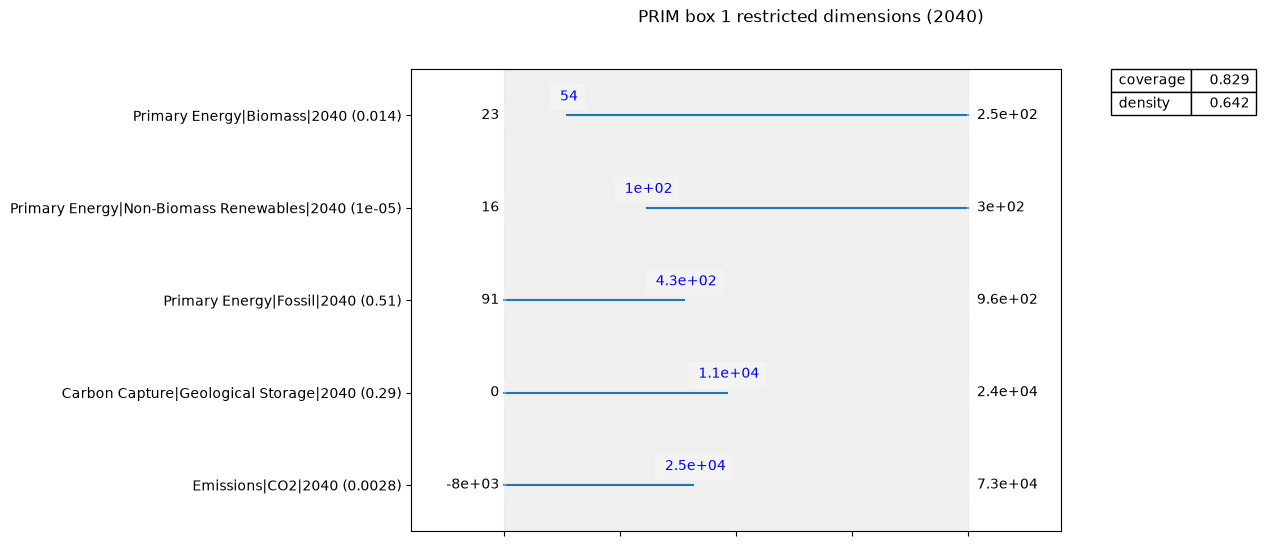

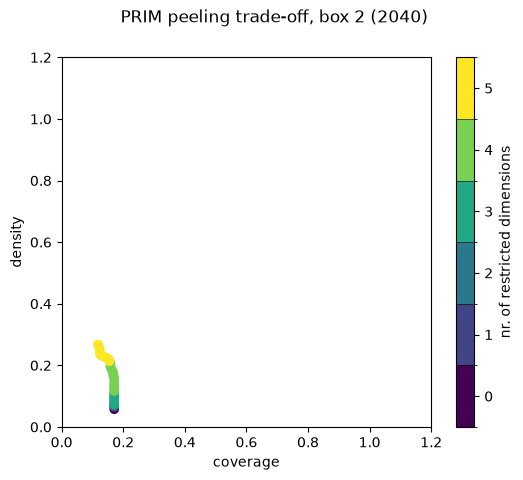


PRIM box statistics (2040):


,coverage,density,mass,res_dim
box 1,0.829193,0.641827,0.30365,5
box 2,0.118012,0.267606,0.10365,5


In [20]:
prim_2040 = run_discovery(2040)

## 4. Run at 2050 (mid-century energy/climate mix)

===== 2050 =====
1370/1599 scenarios complete on all 6 factors
322 desired cases, baseline density = 23.5%



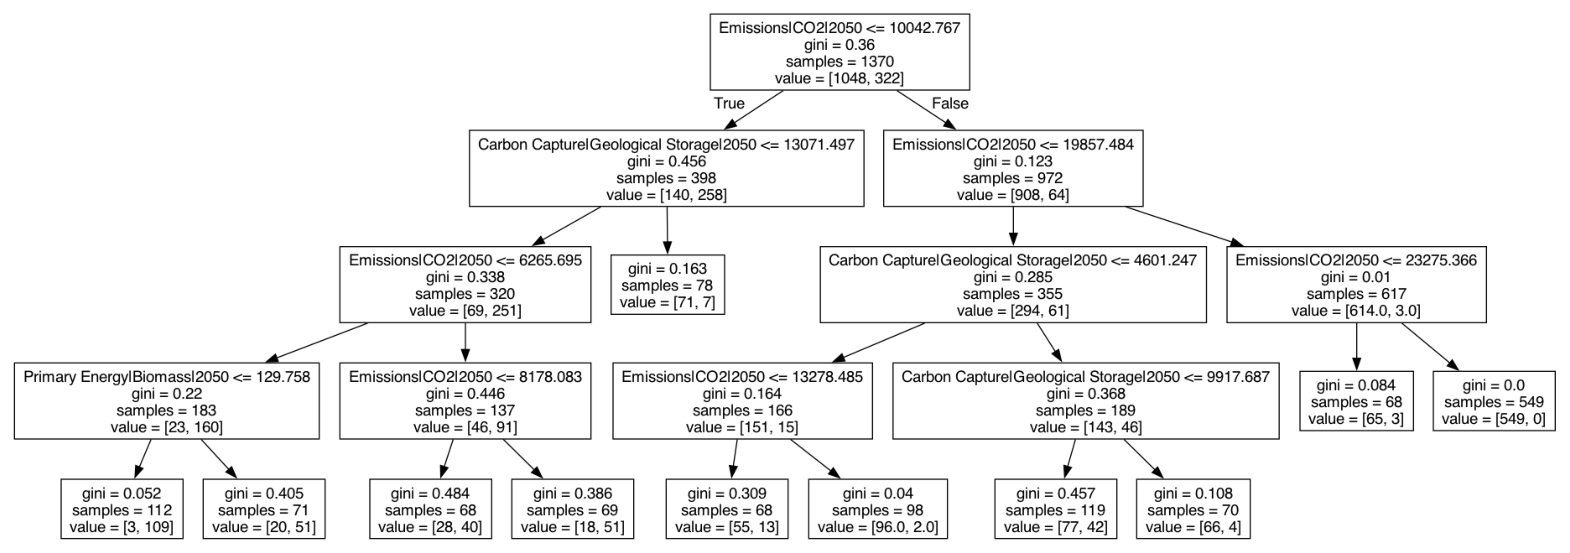

CART feature importances (non-zero):


,importance
Emissions|CO2|2050,0.733899
Carbon Capture|Geological Storage|2050,0.246841
Primary Energy|Biomass|2050,0.019260


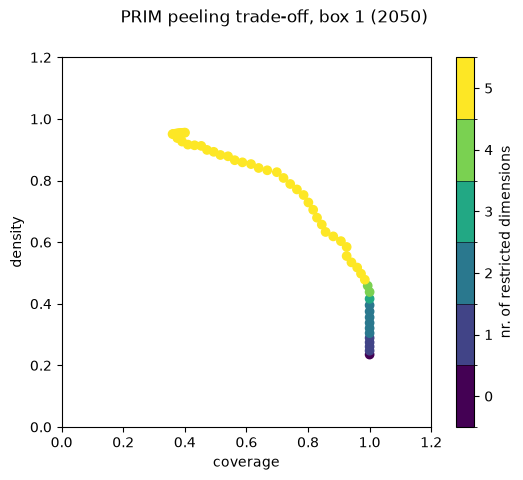

selected box 26 (coverage >= 0.8, max density)
coverage      0.801242
density       0.728814
id           26.000000
k           258.000000
mass          0.258394
mean          0.728814
n           354.000000
res_dim       5.000000
Name: 26, dtype: float64

                                                 box 26                \
                                                    min           max   
Emissions|CO2|2050                         -8996.212513  11389.539791   
Carbon Capture|Geological Storage|2050         0.000000  14378.241279   
Primary Energy|Fossil|2050                    42.077433    438.809180   
Primary Energy|Non-Biomass Renewables|2050   129.340066    473.451635   
Primary Energy|Biomass|2050                   62.888765    310.100000   

                                                                    
                                            qp value      qp value  
Emissions|CO2|2050                               NaN  2.156320e-09  
Carbon Capture|Geologica

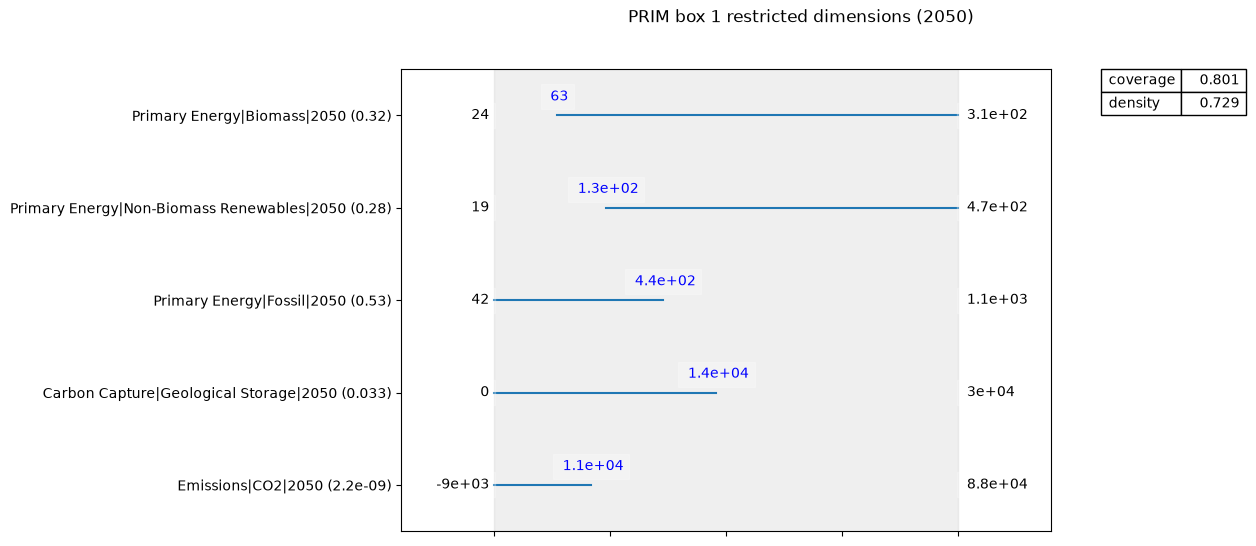

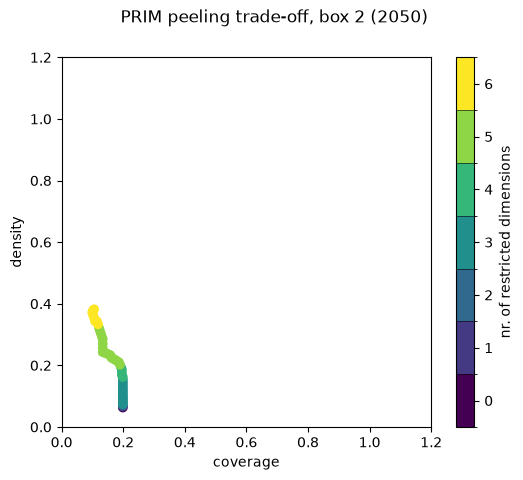


PRIM box statistics (2050):


,coverage,density,mass,res_dim
box 1,0.801242,0.728814,0.258394,5
box 2,0.105590,0.382022,0.064964,6


In [21]:
prim_2050 = run_discovery(2050)

## Caveat

These factors are model **outputs**, not controlled inputs (the ensemble is a heterogeneous
multi-model collection), so the boxes are **descriptive/diagnostic**, not causal. The outcome is a
single threshold choice (NZ <= 2070, cumulative CCS <= 1000 Gt); per the methodology reference it's
worth re-running with neighbouring thresholds before treating the restricted dimensions as a stable
finding. And as flagged in section 1, GSAT temperature and BECCS are partly mechanically linked to
the outcome - the robust, forward-looking part of each box is its energy-mix and near-term-CO2
structure.